### Probit Aggregation Method for Numeric Forecasts
**Date:** January 21, 2026

**Objective:** Test alternate aggregation method using probit (normal) fit instead of GPR.

**Approach:**
1. Sort scenario values and assign percentiles
2. Transform percentiles to z-scores (probit scale)
3. Linear regression of values against z-scores
4. Extract any percentile from fitted line

**Why this might work better:**
- Assumes normal distribution, which smooths the curve
- Allows extrapolation to extreme percentiles (p1, p99)
- Avoids GPR edge artifacts at high/low percentiles

In [1]:
#!pip install probscale  # uncomment if needed

In [2]:
import numpy as np, pandas as pd, json
from scipy.integrate import quad
from scipy.interpolate import splrep, splev
from scipy.stats import linregress
import probscale, matplotlib.pyplot as plt

### Core Functions: Probit Transformation

In [3]:
# Function for normal distribution pdf
def pdf_normal(z): 
    return (1 / ((2 * np.pi))**0.5) * np.exp(-0.5 * (z**2))

# Percentile from z, integrate from neg infinity to z
def pcntl_from_z(z):
    return quad(pdf_normal, -np.inf, z)[0]

# z value from percentile by interpolating forward percentile from z
def z_from_pcntl(percentile):
    x = [pcntl_from_z(z) for z in np.arange(-7, 7.01, 0.01)]
    z = list(np.arange(-7, 7.01, 0.01))
    zspline = splrep(x, z)
    return splev(percentile, zspline)

### Load Scenario Data

In [4]:
# Load numeric scenario files
data_dir = '../all_forecast_summaries/'

with open(data_dir + '41614_unknown_scenarios_1.json', 'r') as f:
    q41614 = json.load(f)

with open(data_dir + '41619_unknown_scenarios_1.json', 'r') as f:
    q41619 = json.load(f)

print(f"Q41614: {q41614['metadata']['question_text'][:60]}...")
print(f"Q41619: {q41619['metadata']['question_text'][:60]}...")

Q41614: What will be the value of "ICE BofA Single-A US Corporate In...
Q41619: What will be the value of "Market Yield on U.S. Treasury Sec...


In [5]:
# Extract raw scenario values
scenarios_41614 = np.array(q41614['scenarios']['raw_values'])
scenarios_41619 = np.array(q41619['scenarios']['raw_values'])

print(f"Q41614: {len(scenarios_41614)} scenarios, range [{scenarios_41614.min():.2f}, {scenarios_41614.max():.2f}]")
print(f"Q41619: {len(scenarios_41619)} scenarios, range [{scenarios_41619.min():.2f}, {scenarios_41619.max():.2f}]")

Q41614: 36 scenarios, range [4.25, 5.30]
Q41619: 36 scenarios, range [4.25, 5.55]


### Probit Fit Function

In [6]:
def probit_fit(data, key_pctls=np.array([1, 5, 10, 25, 50, 75, 90, 95, 99])):
    """
    Fit normal distribution to data using probit regression.
    
    Returns: dict with slope, intercept, r2, and key percentile values
    """
    # Prep data
    data_sorted = np.sort(data)
    n_points = data.shape[0]
    pctl = 100 * np.array(range(1, n_points + 1)) / (n_points + 1)
    
    # Linearize: convert percentiles to z-scores
    ztile = z_from_pcntl(pctl / 100)
    
    # Regression of data values against z
    slope, intercept, r_value, p_value, std_err = linregress(ztile, data_sorted)
    
    # Evaluate regression for key percentiles
    key_ztile = z_from_pcntl(key_pctls / 100)
    key_values = [z * slope + intercept for z in key_ztile]
    
    return {
        'slope': slope,           # ~ standard deviation
        'intercept': intercept,   # ~ mean (value at z=0, i.e., p50)
        'r2': r_value**2,
        'key_pctls': key_pctls,
        'key_values': key_values,
        'data_sorted': data_sorted,
        'data_pctl': pctl,
        'data_ztile': ztile
    }

### Apply Probit Fit to Q41614

In [7]:
# Fit Q41614
fit_41614 = probit_fit(scenarios_41614)

print(f"Probit Fit Results for Q41614:")
print(f"  Slope (std):     {fit_41614['slope']:.4f}")
print(f"  Intercept (mean): {fit_41614['intercept']:.4f}")
print(f"  R-squared:       {fit_41614['r2']:.4f}")
print()
print("Key Percentiles:")
for p, v in zip(fit_41614['key_pctls'], fit_41614['key_values']):
    print(f"  p{p:2d}: {v:.4f}")

Probit Fit Results for Q41614:
  Slope (std):     0.3068
  Intercept (mean): 4.7283
  R-squared:       0.9779

Key Percentiles:
  p 1: 4.0147
  p 5: 4.2238
  p10: 4.3352
  p25: 4.5214
  p50: 4.7283
  p75: 4.9352
  p90: 5.1215
  p95: 5.2329
  p99: 5.4420


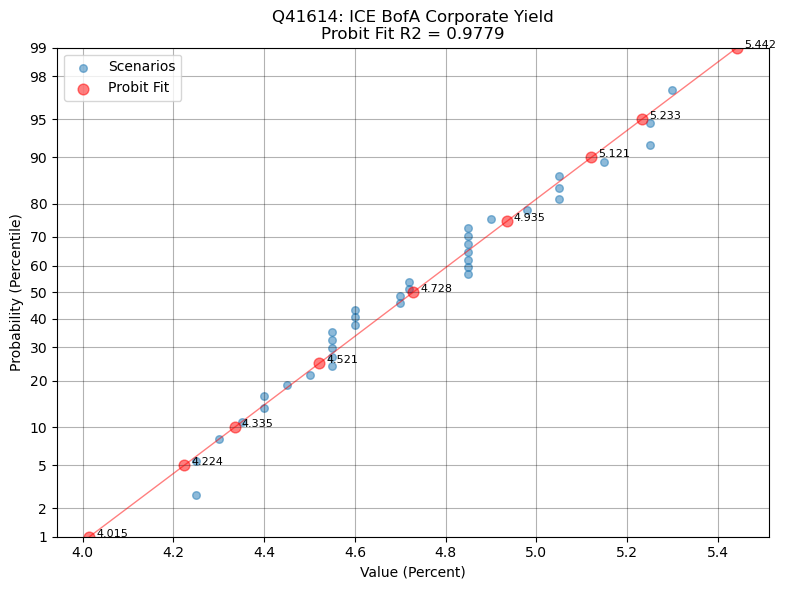

In [8]:
# Plot Q41614 probit fit
r2 = round(fit_41614['r2'], 4)

plt.figure(figsize=(8, 6))
plt.scatter(fit_41614['data_sorted'], fit_41614['data_pctl'], alpha=0.5, s=30, label='Scenarios')
plt.scatter(fit_41614['key_values'], fit_41614['key_pctls'], c='r', s=60, alpha=0.5, label='Probit Fit')
plt.plot(fit_41614['key_values'], fit_41614['key_pctls'], 'r-', alpha=0.5, linewidth=1)

for i, (p, v) in enumerate(zip(fit_41614['key_pctls'], fit_41614['key_values'])):
    plt.annotate(f'{v:.3f}', (v, p), fontsize=8, xytext=(5, 0), textcoords='offset points')

plt.title(f"Q41614: ICE BofA Corporate Yield\nProbit Fit R2 = {r2}", fontsize=12)
plt.xlabel("Value (Percent)", fontsize=10)
plt.ylabel("Probability (Percentile)", fontsize=10)
plt.grid(color='black', alpha=0.3)
plt.grid(visible=True, which='minor', alpha=0.2)
plt.ylim(1, 99)
plt.yscale('prob')
plt.legend()
plt.tight_layout()
plt.show()

### Apply Probit Fit to Q41619

In [9]:
# Fit Q41619
fit_41619 = probit_fit(scenarios_41619)

print(f"Probit Fit Results for Q41619:")
print(f"  Slope (std):     {fit_41619['slope']:.4f}")
print(f"  Intercept (mean): {fit_41619['intercept']:.4f}")
print(f"  R-squared:       {fit_41619['r2']:.4f}")
print()
print("Key Percentiles:")
for p, v in zip(fit_41619['key_pctls'], fit_41619['key_values']):
    print(f"  p{p:2d}: {v:.4f}")

Probit Fit Results for Q41619:
  Slope (std):     0.3339
  Intercept (mean): 4.8247
  R-squared:       0.9857

Key Percentiles:
  p 1: 4.0479
  p 5: 4.2754
  p10: 4.3968
  p25: 4.5995
  p50: 4.8247
  p75: 5.0500
  p90: 5.2527
  p95: 5.3740
  p99: 5.6016


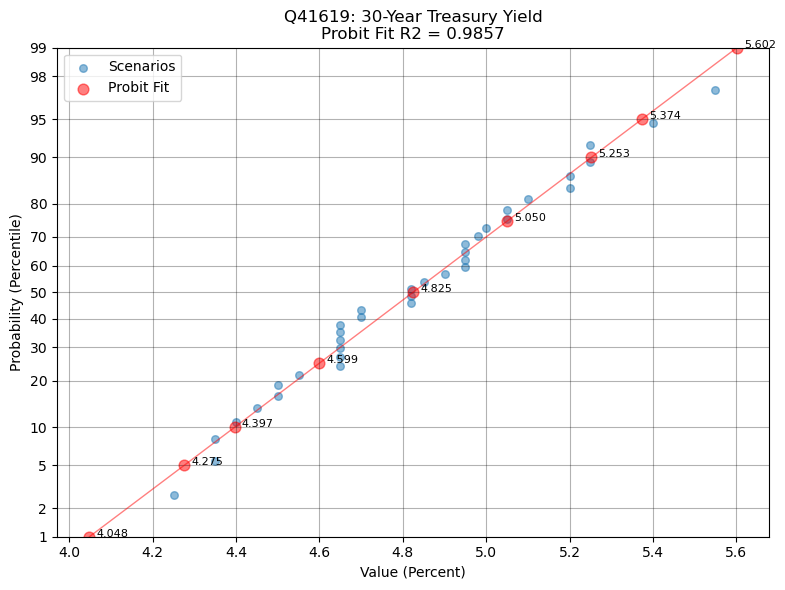

In [10]:
# Plot Q41619 probit fit
r2 = round(fit_41619['r2'], 4)

plt.figure(figsize=(8, 6))
plt.scatter(fit_41619['data_sorted'], fit_41619['data_pctl'], alpha=0.5, s=30, label='Scenarios')
plt.scatter(fit_41619['key_values'], fit_41619['key_pctls'], c='r', s=60, alpha=0.5, label='Probit Fit')
plt.plot(fit_41619['key_values'], fit_41619['key_pctls'], 'r-', alpha=0.5, linewidth=1)

for i, (p, v) in enumerate(zip(fit_41619['key_pctls'], fit_41619['key_values'])):
    plt.annotate(f'{v:.3f}', (v, p), fontsize=8, xytext=(5, 0), textcoords='offset points')

plt.title(f"Q41619: 30-Year Treasury Yield\nProbit Fit R2 = {r2}", fontsize=12)
plt.xlabel("Value (Percent)", fontsize=10)
plt.ylabel("Probability (Percentile)", fontsize=10)
plt.grid(color='black', alpha=0.3)
plt.grid(visible=True, which='minor', alpha=0.2)
plt.ylim(1, 99)
plt.yscale('prob')
plt.legend()
plt.tight_layout()
plt.show()

### Compare Probit vs GPR Aggregation

In [11]:
def compare_probit_vs_gpr(scenarios_json, fit_result, title):
    """
    Compare probit fit percentiles with existing GPR percentiles.
    """
    gpr_pctls = scenarios_json['aggregated_result']['percentiles']
    
    # Get probit values at same percentiles as GPR (5, 10, 15, ..., 95)
    gpr_percentiles = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
    probit_fit_full = probit_fit(np.array(scenarios_json['scenarios']['raw_values']), 
                                  key_pctls=np.array(gpr_percentiles))
    
    comparison_df = pd.DataFrame({
        'percentile': gpr_percentiles,
        'GPR': [gpr_pctls[f'p{p}'] for p in gpr_percentiles],
        'Probit': probit_fit_full['key_values']
    })
    comparison_df['Diff'] = comparison_df['Probit'] - comparison_df['GPR']
    comparison_df['Diff_pct'] = 100 * comparison_df['Diff'] / comparison_df['GPR']
    
    print(f"\n{title}")
    print(f"Probit R2: {probit_fit_full['r2']:.4f}")
    print(comparison_df.to_string(index=False))
    
    return comparison_df, probit_fit_full

In [12]:
# Compare Q41614
comp_41614, probit_full_41614 = compare_probit_vs_gpr(q41614, fit_41614, "Q41614: ICE BofA Corporate Yield")


Q41614: ICE BofA Corporate Yield
Probit R2: 0.9779
 percentile      GPR   Probit      Diff  Diff_pct
          5 4.268255 4.223755 -0.044500 -1.042583
         10 4.339736 4.335202 -0.004534 -0.104476
         15 4.403085 4.410395  0.007310  0.166010
         20 4.459132 4.470156  0.011024  0.247230
         25 4.508866 4.521425  0.012560  0.278552
         30 4.553422 4.567467  0.014045  0.308450
         35 4.594051 4.610132  0.016081  0.350037
         40 4.632091 4.650616  0.018525  0.399925
         45 4.668940 4.689785  0.020845  0.446472
         50 4.706016 4.728333  0.022317  0.474233
         55 4.744727 4.766881  0.022155  0.466931
         60 4.786432 4.806051  0.019619  0.409883
         65 4.832406 4.846535  0.014129  0.292378
         70 4.883807 4.889200  0.005393  0.110424
         75 4.941640 4.935241 -0.006399 -0.129483
         80 5.006732 4.986511 -0.020221 -0.403877
         85 5.079704 5.046272 -0.033432 -0.658145
         90 5.160949 5.121465 -0.039484 -0.76505

In [13]:
# Compare Q41619
comp_41619, probit_full_41619 = compare_probit_vs_gpr(q41619, fit_41619, "Q41619: 30-Year Treasury Yield")


Q41619: 30-Year Treasury Yield
Probit R2: 0.9857
 percentile      GPR   Probit      Diff  Diff_pct
          5 4.310073 4.275437 -0.034636 -0.803604
         10 4.394794 4.396759  0.001965  0.044713
         15 4.470070 4.478614  0.008544  0.191136
         20 4.536457 4.543670  0.007212  0.158986
         25 4.594756 4.599482  0.004726  0.102858
         30 4.645999 4.649603  0.003604  0.077562
         35 4.691441 4.696048  0.004607  0.098197
         40 4.732528 4.740119  0.007591  0.160404
         45 4.770875 4.782759  0.011883  0.249077
         50 4.808230 4.824722  0.016492  0.342993
         55 4.846432 4.866686  0.020254  0.417919
         60 4.887368 4.909325  0.021958  0.449276
         65 4.932929 4.953397  0.020468  0.414925
         70 4.984959 4.999841  0.014882  0.298537
         75 5.045208 5.049962  0.004754  0.094234
         80 5.115280 5.105775 -0.009505 -0.185817
         85 5.196588 5.170831 -0.025757 -0.495660
         90 5.290313 5.252686 -0.037627 -0.711245


### Visual Comparison: Probit vs GPR

In [14]:
def plot_comparison(scenarios_json, probit_fit_full, title):
    """
    Plot both GPR and Probit distributions on same chart.
    """
    gpr_pctls = scenarios_json['aggregated_result']['percentiles']
    gpr_percentiles = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
    gpr_values = [gpr_pctls[f'p{p}'] for p in gpr_percentiles]
    
    data_sorted = np.sort(np.array(scenarios_json['scenarios']['raw_values']))
    n_points = len(data_sorted)
    data_pctl = 100 * np.array(range(1, n_points + 1)) / (n_points + 1)
    
    plt.figure(figsize=(10, 7))
    
    # Raw scenarios
    plt.scatter(data_sorted, data_pctl, alpha=0.4, s=25, c='gray', label='Raw Scenarios')
    
    # GPR fit
    plt.plot(gpr_values, gpr_percentiles, 'b-o', alpha=0.7, linewidth=2, markersize=4, label='GPR')
    
    # Probit fit
    plt.plot(probit_fit_full['key_values'], probit_fit_full['key_pctls'], 'r-s', 
             alpha=0.7, linewidth=2, markersize=4, label=f'Probit (R2={probit_fit_full["r2"]:.3f})')
    
    plt.title(f"{title}\nGPR vs Probit Aggregation", fontsize=12)
    plt.xlabel("Value", fontsize=10)
    plt.ylabel("Probability (Percentile)", fontsize=10)
    plt.grid(color='black', alpha=0.3)
    plt.grid(visible=True, which='minor', alpha=0.2)
    plt.ylim(1, 99)
    plt.yscale('prob')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

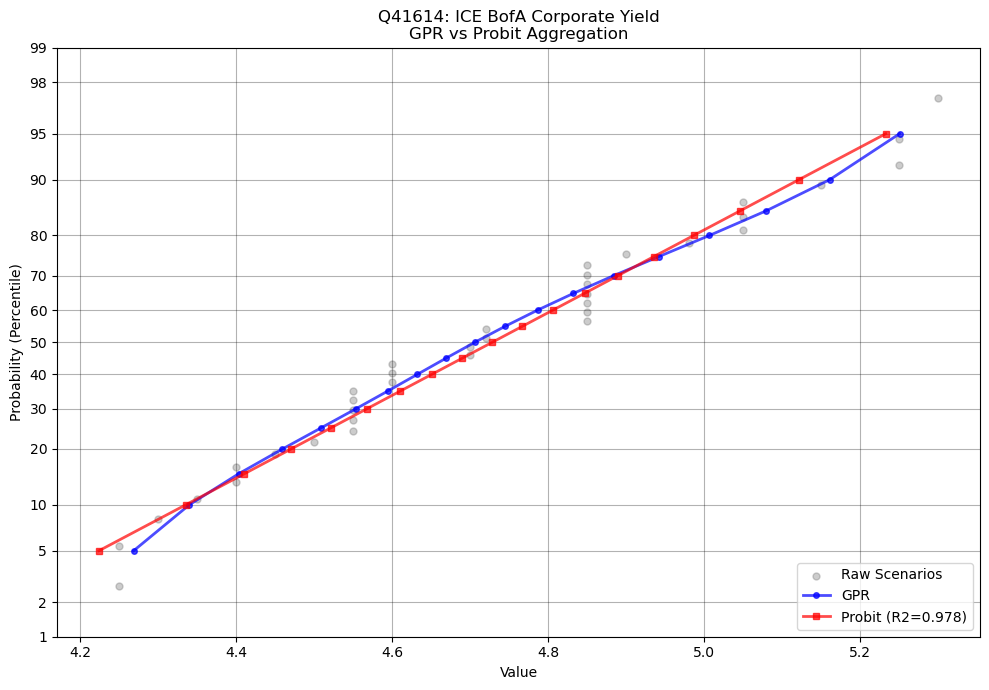

In [15]:
plot_comparison(q41614, probit_full_41614, "Q41614: ICE BofA Corporate Yield")

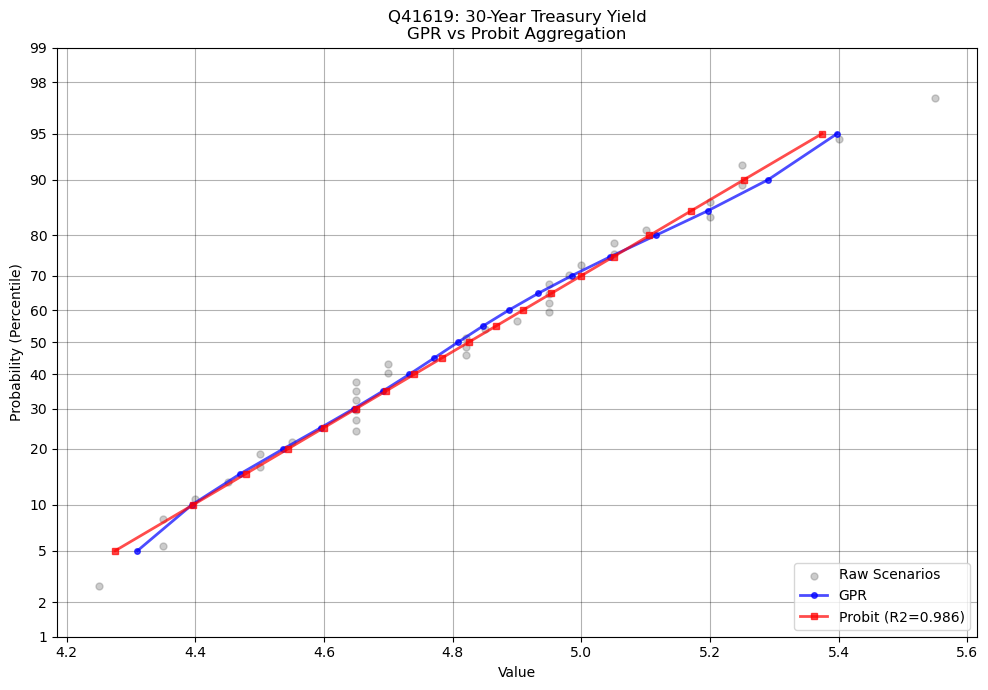

In [16]:
plot_comparison(q41619, probit_full_41619, "Q41619: 30-Year Treasury Yield")

### Generate Full Distribution (p1 to p99)

In [17]:
def generate_full_distribution(data, output_percentiles=list(range(1, 100))):
    """
    Generate full distribution from p1 to p99 using probit fit.
    """
    # Prep data
    data_sorted = np.sort(data)
    n_points = data.shape[0]
    pctl = 100 * np.array(range(1, n_points + 1)) / (n_points + 1)
    
    # Linearize and regress
    ztile = z_from_pcntl(pctl / 100)
    slope, intercept, r_value, p_value, std_err = linregress(ztile, data_sorted)
    
    # Generate distribution
    output_ztile = z_from_pcntl(np.array(output_percentiles) / 100)
    output_values = [z * slope + intercept for z in output_ztile]
    
    return pd.DataFrame({
        'percentile': output_percentiles,
        'value': output_values
    }), {'slope': slope, 'intercept': intercept, 'r2': r_value**2}

In [18]:
# Generate full distribution for Q41614
dist_41614, stats_41614 = generate_full_distribution(scenarios_41614)
print(f"Q41614 Full Distribution (p1-p99):")
print(f"  Mean (p50): {stats_41614['intercept']:.4f}")
print(f"  Std (slope): {stats_41614['slope']:.4f}")
print(f"  R2: {stats_41614['r2']:.4f}")
print()
display(dist_41614.head(10))
display(dist_41614.tail(10))

Q41614 Full Distribution (p1-p99):
  Mean (p50): 4.7283
  Std (slope): 0.3068
  R2: 0.9779



,percentile,value
0,1,4.014698
1,2,4.098321
2,3,4.151377
3,4,4.191289
4,5,4.223755
5,6,4.251388
6,7,4.275617
7,8,4.297311
8,9,4.317041
9,10,4.335202


,percentile,value
89,90,5.121465
90,91,5.139626
91,92,5.159356
92,93,5.181050
93,94,5.205279
94,95,5.232912
95,96,5.265377
96,97,5.305289
97,98,5.358346
98,99,5.441969


### Summary and Next Steps

**Observations:**
- Document R2 values and visual fit quality
- Compare smoothness at tails (p1-p10, p90-p99) between GPR and Probit
- Note any systematic differences

**Next Steps:**
1. Test on more numeric questions
2. Consider segmented fit (separate curves for p0-50 and p50-100)
3. Integrate into main.py as alternative aggregation option